In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from bs4 import BeautifulSoup
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [77]:
df = pd.read_csv("F:/MyProjects/PraxisProjects/Email_Spam_Classifier/data/emails.csv")

display(df.shape)
df.head()

(5728, 2)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [78]:
df.isnull().sum().sum()

np.int64(0)

In [79]:
df.duplicated().sum()

np.int64(33)

In [80]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

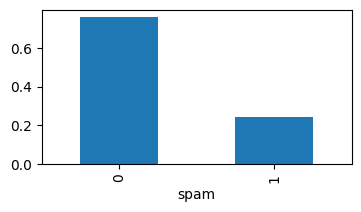

In [81]:
plt.figure(figsize=(4,2))
df["spam"].value_counts(normalize=True).plot(kind='bar')
plt.show()


In [82]:
def clean_text(text, remove_html=True, remove_urls=True, remove_punc=True, remove_numbers=True, remove_subject=True):
    
    # lower case
    text = text.lower()  
    
    # remove html
    if remove_html:
        text = BeautifulSoup(text, "html.parser").get_text()
    
    # remove urls
    if remove_urls:
        text = re.sub(r'http\S+|www\.\S+', '', text)

    # remove subject prefix
    if remove_subject:
        text = re.sub(r'^subject\s*:\s*', '', text)
    
    # remove punctuation
    if remove_punc:
        text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove numbers
    if remove_numbers:
        text = re.sub(r'\d+', '', text)
    
    # remove extra spaces
    text = ' '.join(text.split())
    
    return text

In [83]:
df['text'] = df['text'].apply(clean_text)

In [84]:
stpwords = stopwords.words("english")

def remove_stopwords(txt):
    newtext = []
    for word in txt.split():
        if word in stpwords:
            newtext.append("")
        else:
            newtext.append(word)

    x = newtext[:]

    newtext.clear()
    return " ".join(x)

In [85]:
df['text'] = df["text"].apply(remove_stopwords)

In [86]:
df['text'][3]

'color printing special request additional information  click  click    printable version   order form pdf format phone fax e mail ramsey goldengraphix com request additional information  click  click    printable version   order form pdf format golden graphix printing azusa canyon rd irwindale ca  e mail message   advertisement   solicitation'

In [87]:
df.head()

,text,spam
0,naturally irresistible corporate identity lt ...,1
1,stock trading gunslinger fanny merrill muzo...,1
2,unbelievable new homes made easy im wanting s...,1
3,color printing special request additional info...,1
4,money get software cds software compatibi...,1


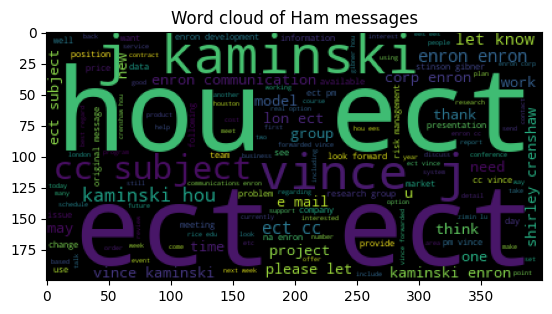

In [88]:
ham_text = df[df['spam'] == 0]['text'].str.cat(sep=' ')

wcloud0 = WordCloud().generate(ham_text)

plt.imshow(wcloud0)
plt.title('Word cloud of Ham messages')
plt.show()

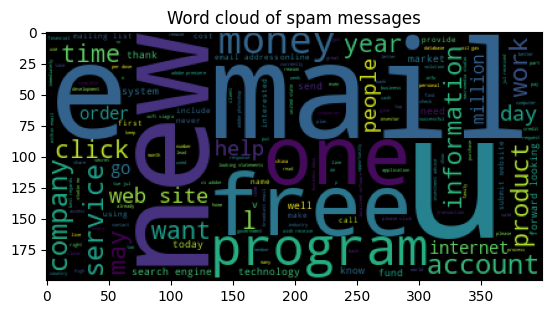

In [89]:
spam_text = df[df['spam'] == 1]['text'].str.cat(sep=' ')

wcloud0 = WordCloud().generate(spam_text)

plt.imshow(wcloud0)
plt.title('Word cloud of spam messages')
plt.show()